In [1]:
import torch
import xarray as xr
import numpy as np
import sys
sys.path.append('/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder')
import utils as ut

In [2]:
def torch_to_dataarray(x_tensor, coords_ds, lat_dim=32, lon_dim=32, name="variable"):
    """
    Convert a flattened 2D torch tensor to a 3D xarray.DataArray (lat, lon, time).

    Parameters:
    ----------
    x_tensor : torch.Tensor
        A 2D tensor of shape (time_steps, lat_dim * lon_dim), or a 1D tensor to be reshaped.
    lat_dim : int
        Number of latitude points.
    lon_dim : int
        Number of longitude points.
    coords_ds : xarray.Dataset
        Dataset containing 'lat', 'lon', and 'time' coordinates to assign.
    name : str, optional
        Name of the variable in the DataArray.

    Returns:
    -------
    xarray.DataArray
        The reshaped and labeled data as an xarray.DataArray.
    """
    # Step 1: Convert to NumPy
    # data_np = x_tensor.detach().cpu().numpy()

    # Step 1: Convert to NumPy
    if isinstance(x_tensor, np.ndarray):
        # x is a NumPy array
        print("input array is numpy array")
        data_np = x_tensor
    elif isinstance(x_tensor, torch.Tensor):
        print("input array is torch tensor")
        data_np = x_tensor.detach().cpu().numpy()

    # Step 2: Determine time_steps and reshape
    print("data_np dimensions:", data_np.ndim)
    #if data_np.ndim == 2:
    #    time_steps = 1
    #elif data_np.ndim > 2:
    time_steps = data_np.shape[0]
    
    data_np = data_np.reshape(time_steps, lat_dim, lon_dim)

    # Step 3: Transpose to (lat, lon, time)
    data_np = data_np.transpose(1, 2, 0)

    # Step 4: Create the DataArray
    da = xr.DataArray(
        data_np,
        dims=("lat", "lon", "time"),
        coords={
            "lat": coords_ds.lat,
            "lon": coords_ds.lon,
            "time": np.arange(time_steps)
        },
        name=name
    )

    return da

In [4]:
import json
# reference dataset

settings_file_path =  "/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder/joint_training/v4_dpa_train_settings.json" #"../joint_training/v2_dpa_train_settings.json"
    
with open(settings_file_path, 'r') as file:
        settings = json.load(file)

# Train data
ds_ref = xr.open_dataset(settings['dataset_trefht'])
ds_ref

<xarray.Dataset> Size: 2GB
Dimensions:  (lat: 32, lon: 32, time: 476900)
Coordinates:
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * time     (time) object 4MB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00
Data variables:
    TREFHT   (lat, lon, time) float32 2GB ...

In [5]:
ds_torch_sample = ut.data_to_torch(ds_ref, "TREFHT")
print(ds_torch_sample.shape)
_, mask_trefht = ut.remove_nan_columns(ds_torch_sample)

torch.Size([476900, 1024])
torch.Size([476900, 1024])


In [6]:
# load StoNet predicted torch ensemble (1d prediction)
torch_ensemble = torch.load("/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/StoNet/v4_data_1d_ger_trained_30_epochs_predictions.pt", map_location="cpu")
torch_ensemble.shape
# analogue_ensemble_member","time","lat","lon"

torch.Size([14307, 1, 100])

0
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


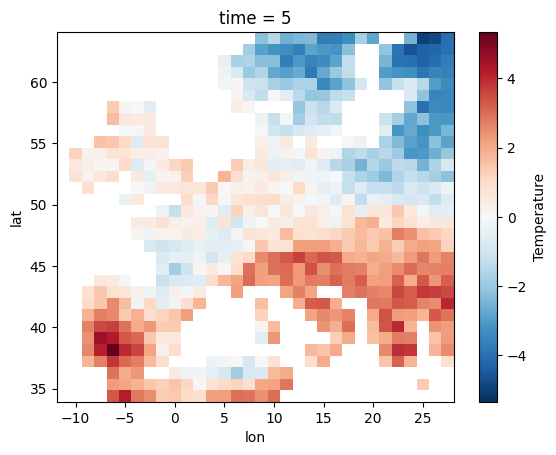

1
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


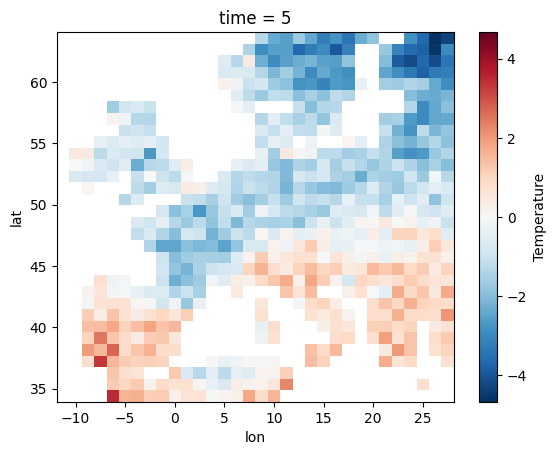

2
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


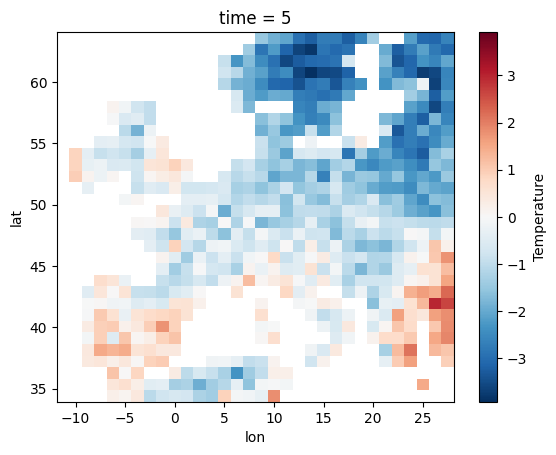

3
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


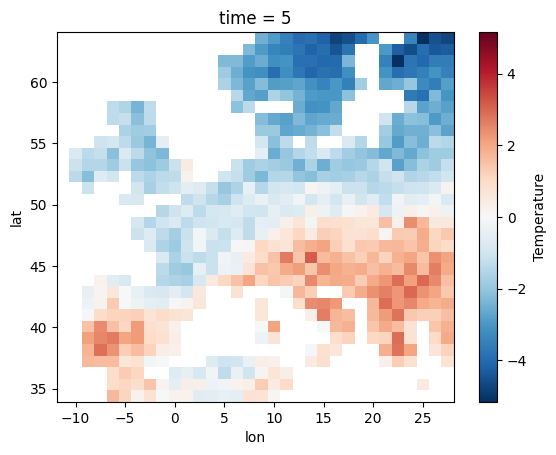

4
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


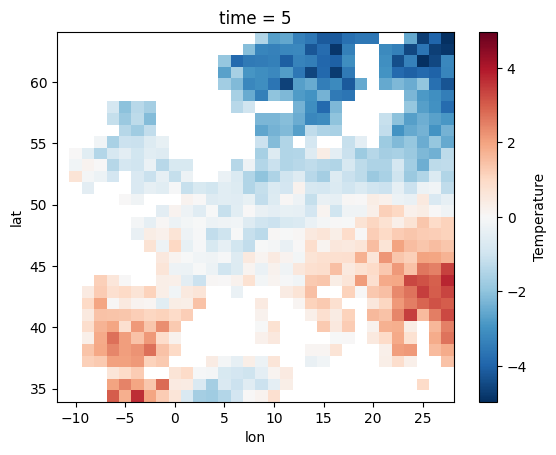

5
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


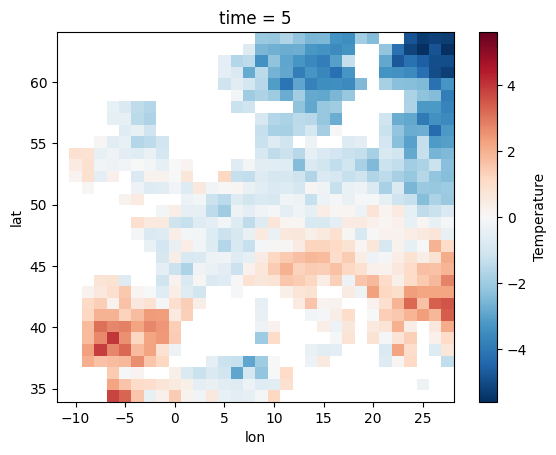

6
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


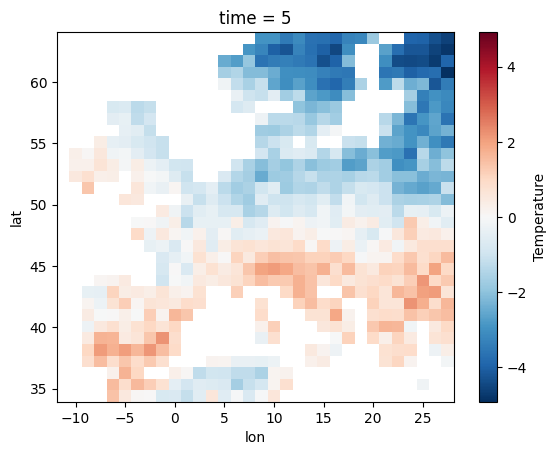

7
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


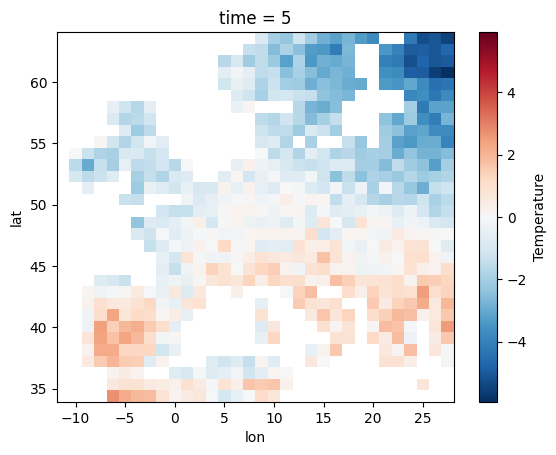

8
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


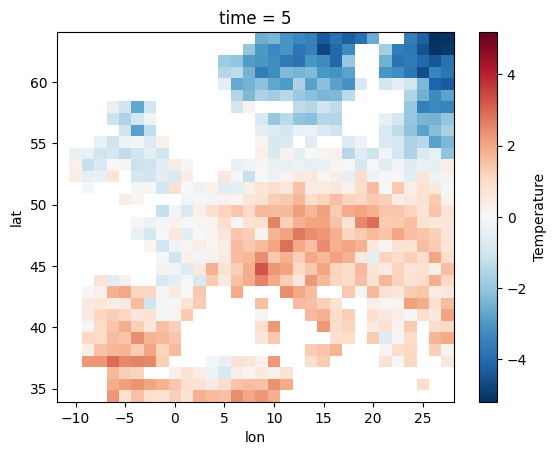

9
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


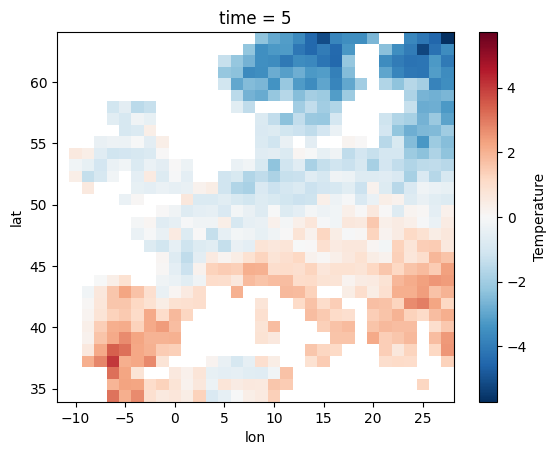

10
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


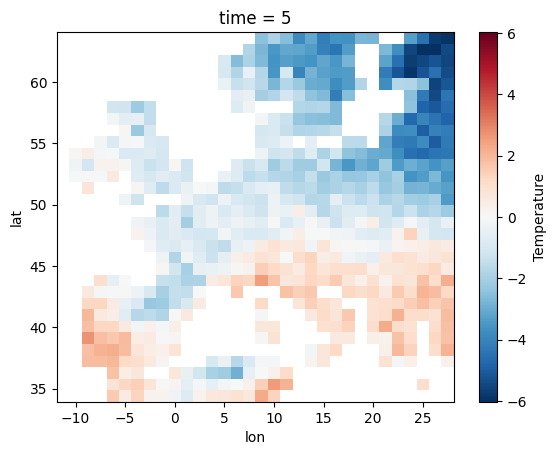

11
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


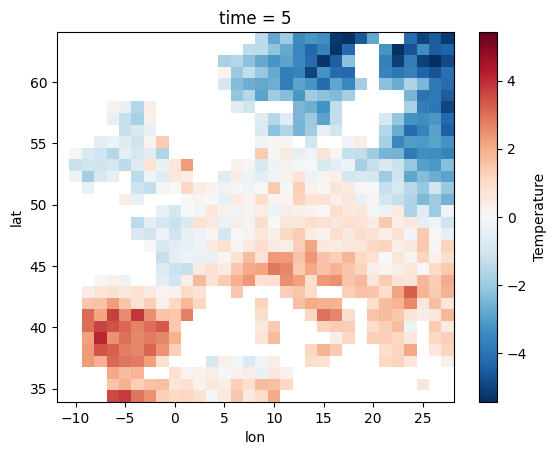

12
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


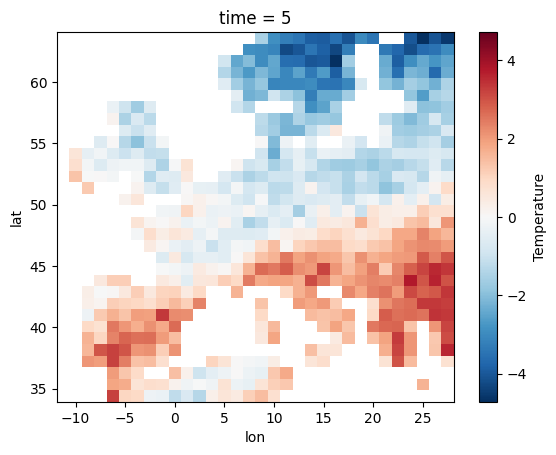

13
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


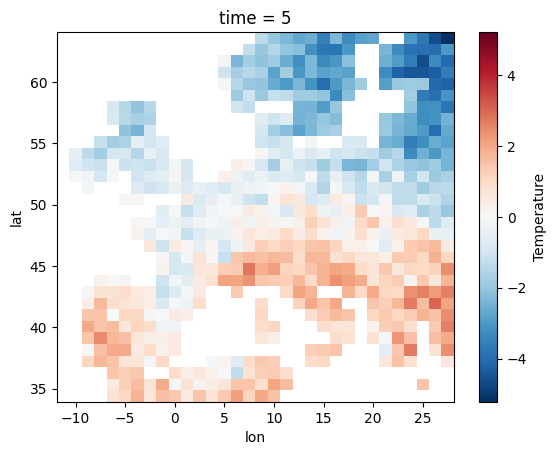

14
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


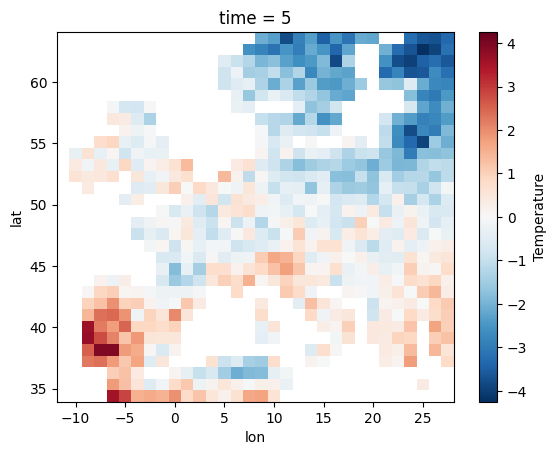

15
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


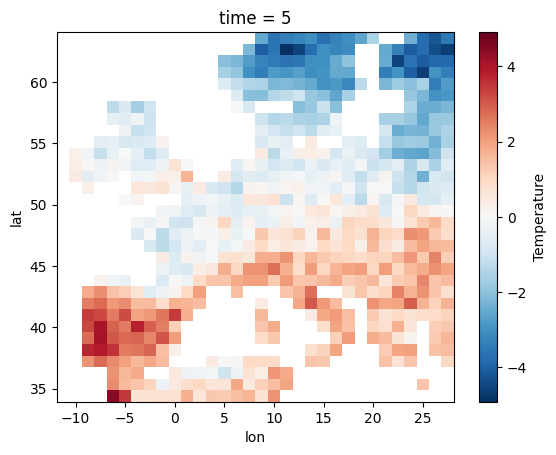

16
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


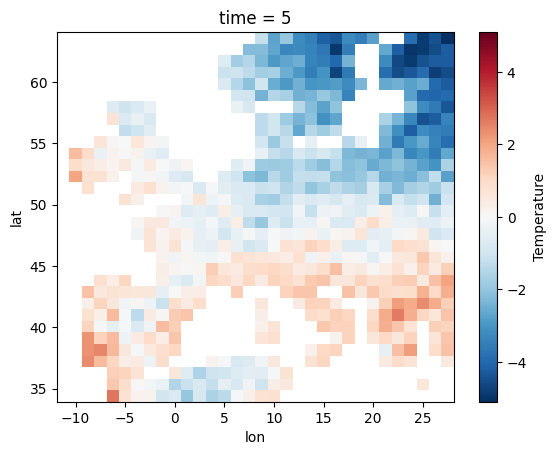

17
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


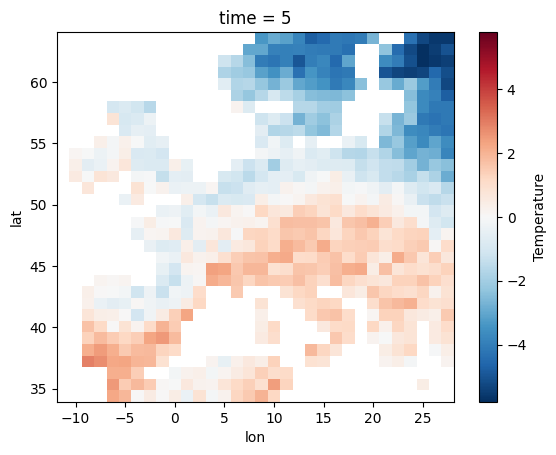

18
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


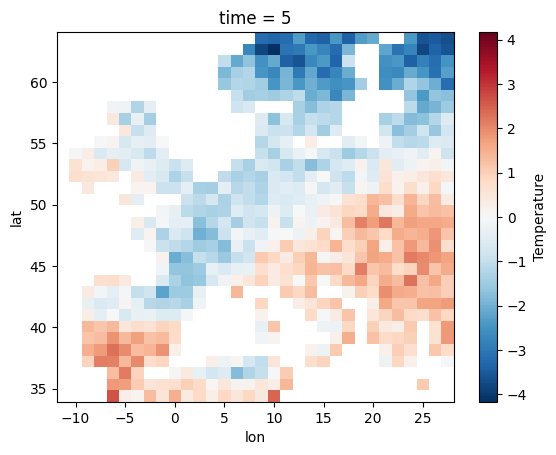

19
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


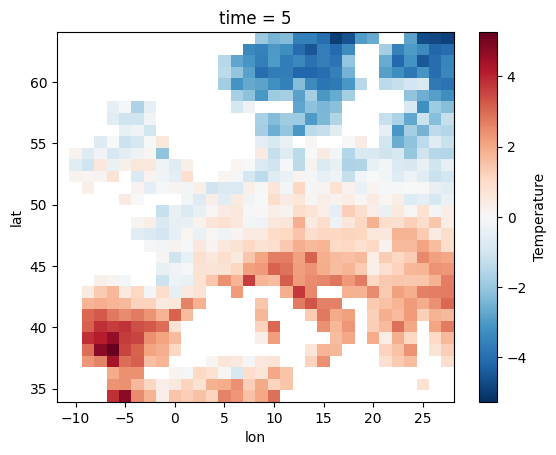

20
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


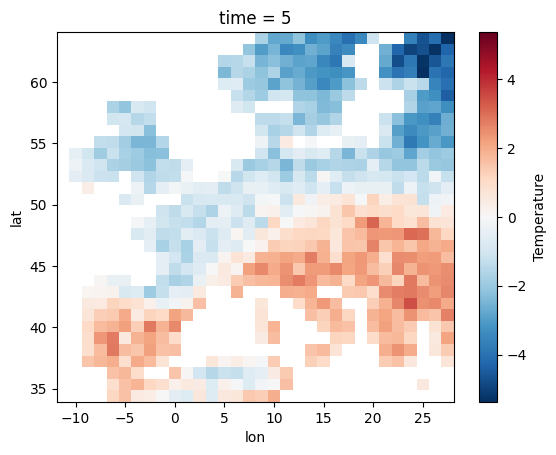

21
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


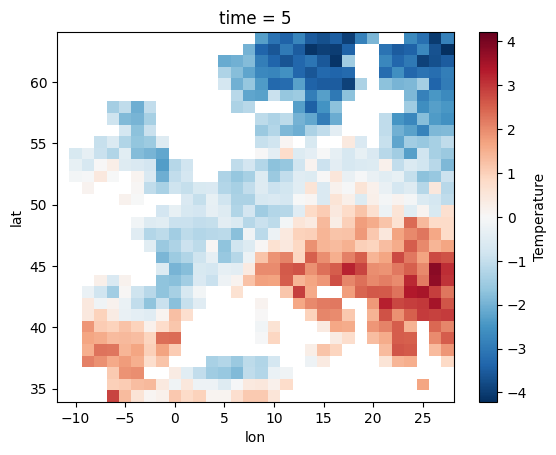

22
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


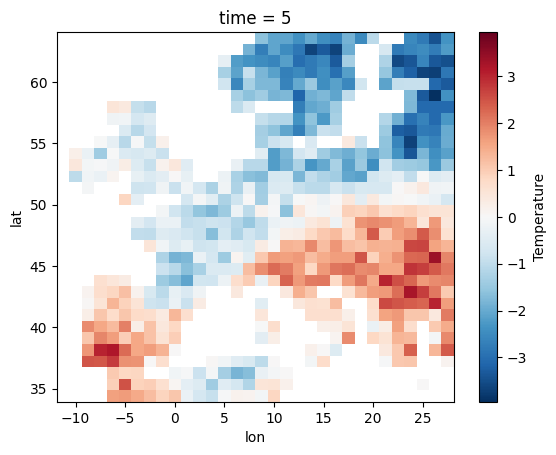

23
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


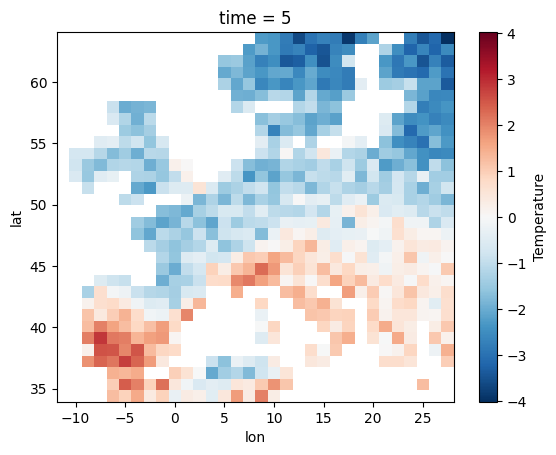

24
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


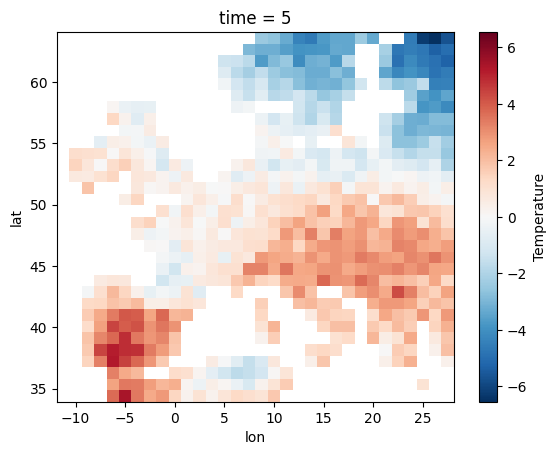

25
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


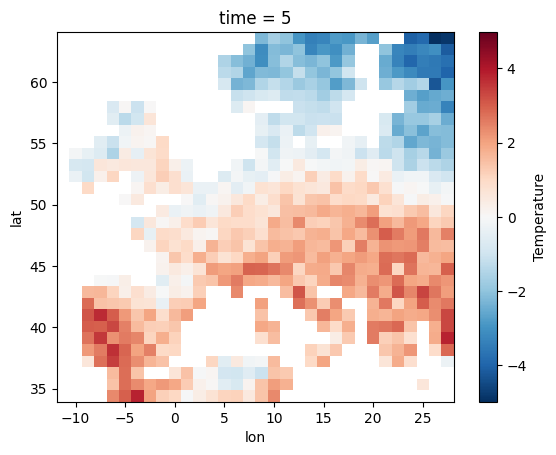

26
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


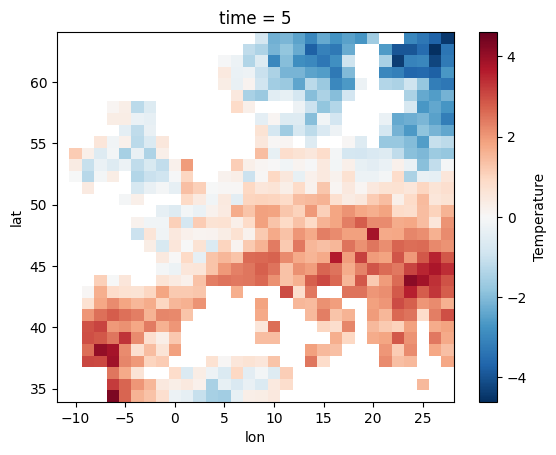

27
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


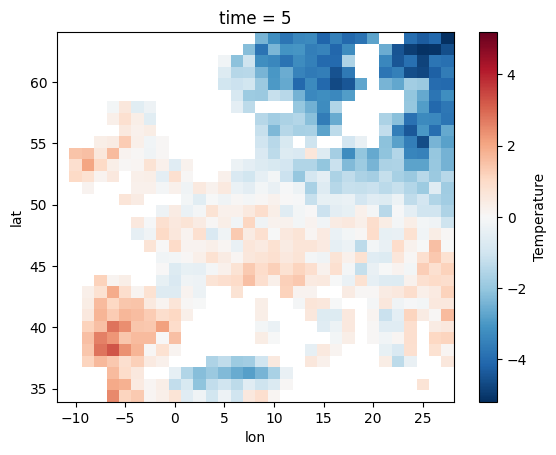

28
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


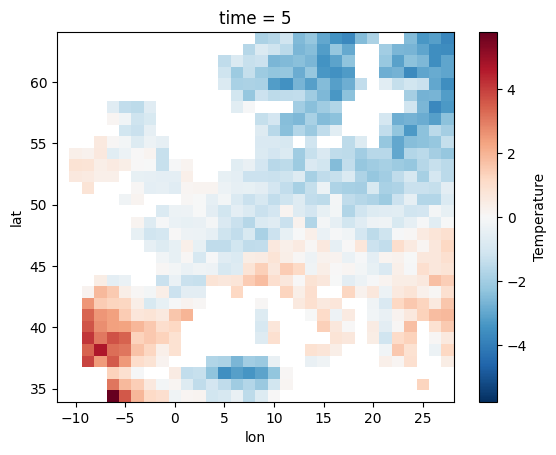

29
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


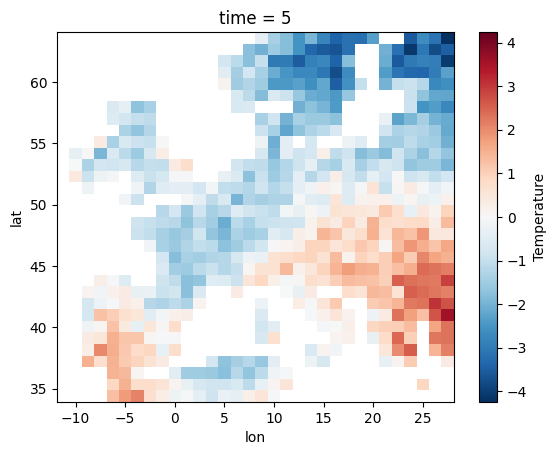

30
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


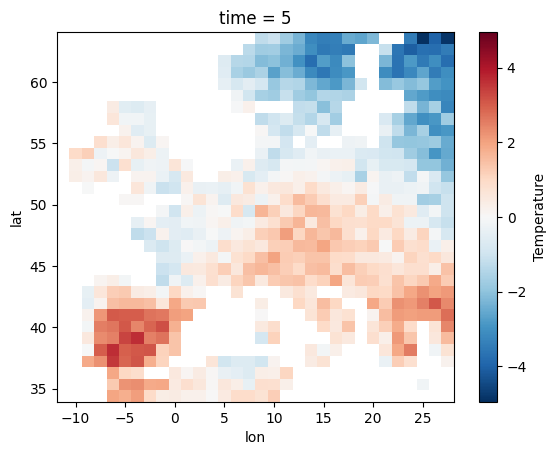

31
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


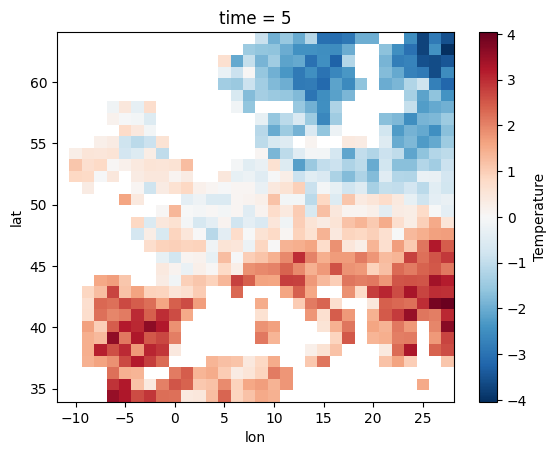

32
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


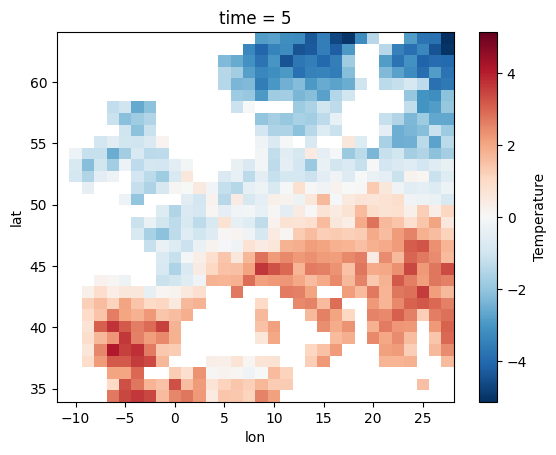

33
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


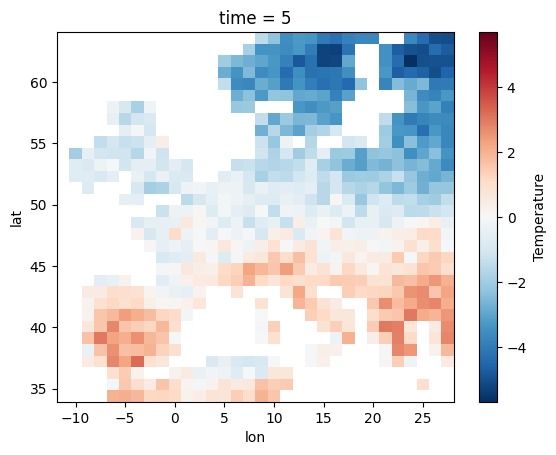

34
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


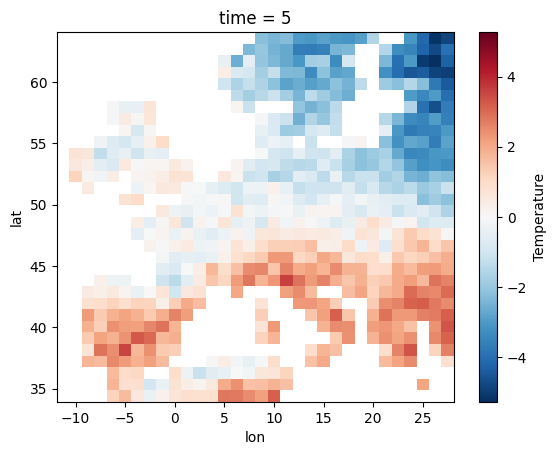

35
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


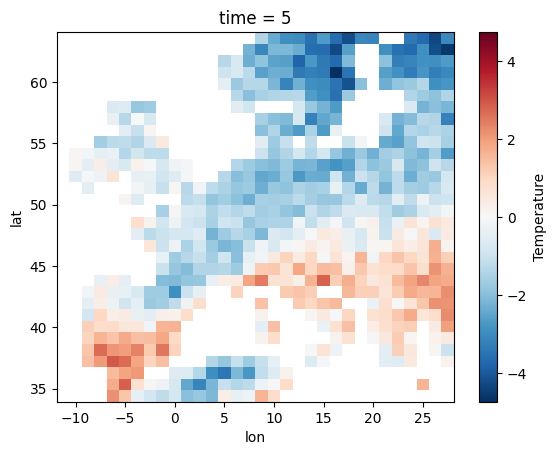

36
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


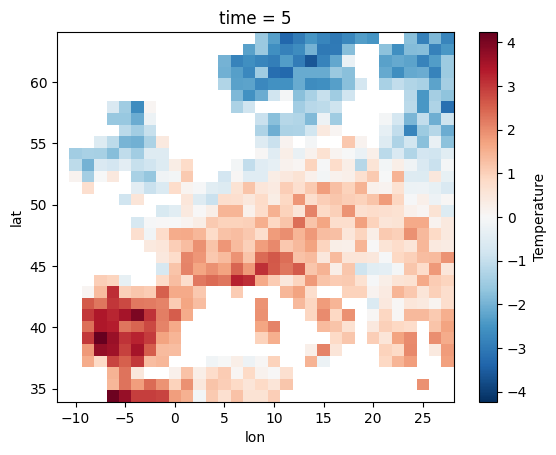

37
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


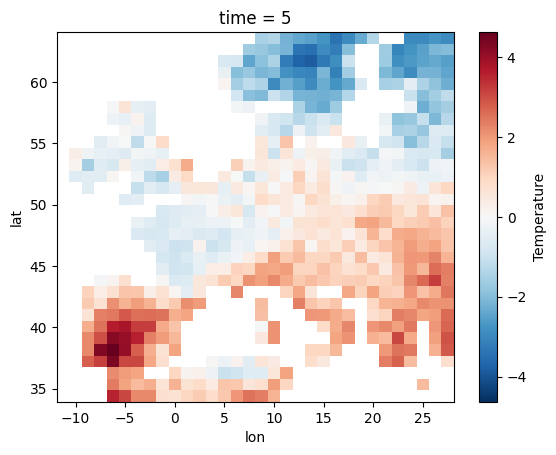

38
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


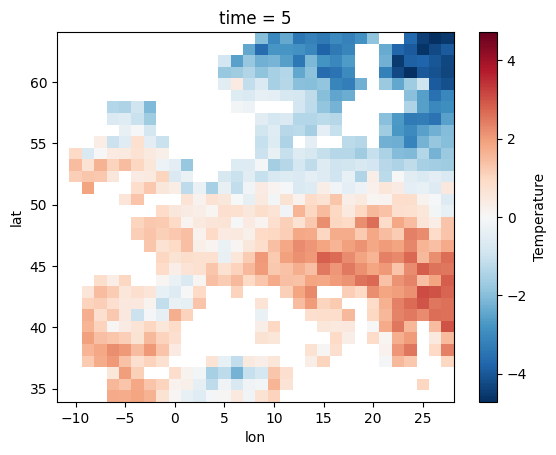

39
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


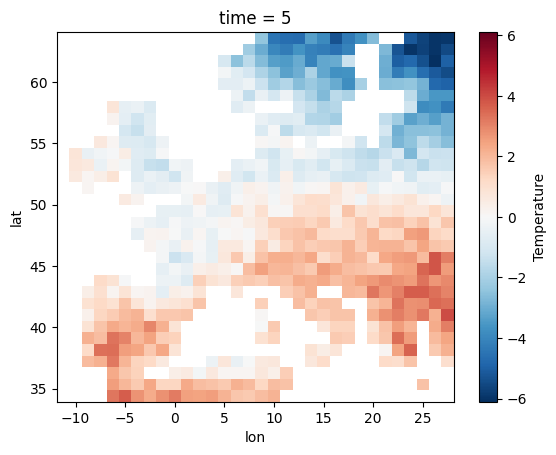

40
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


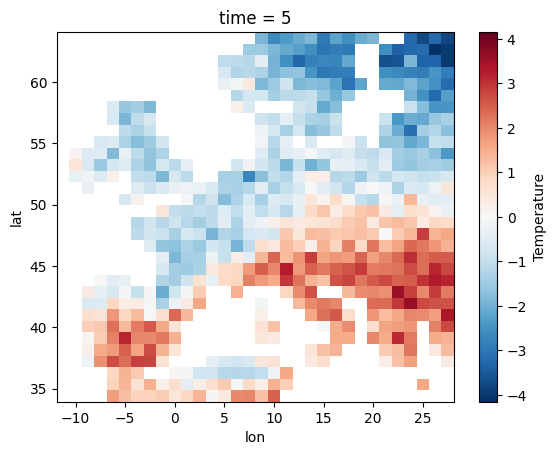

41
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


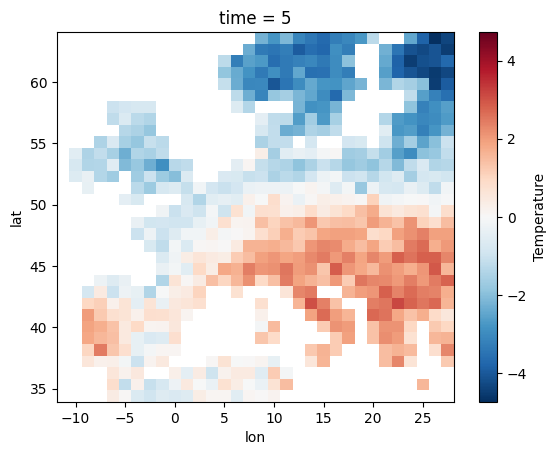

42
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


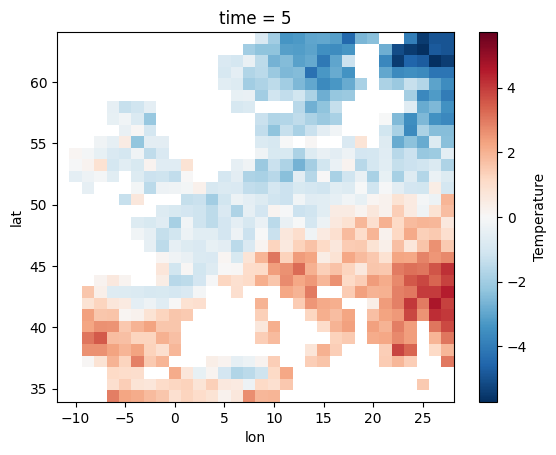

43
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


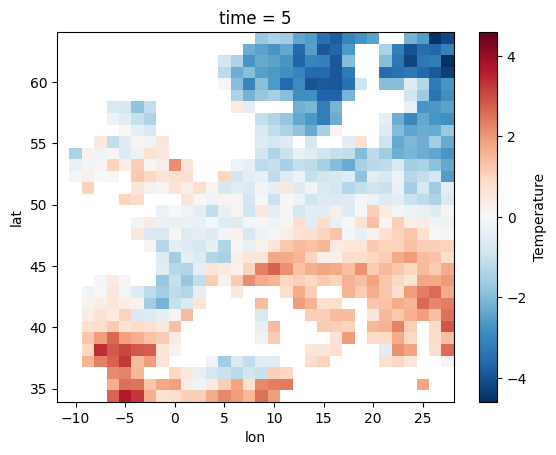

44
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


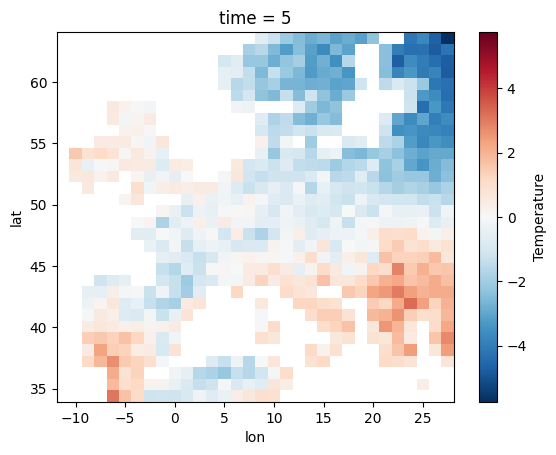

45
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


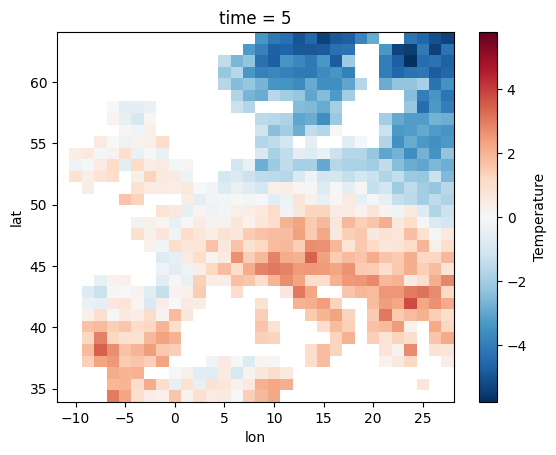

46
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


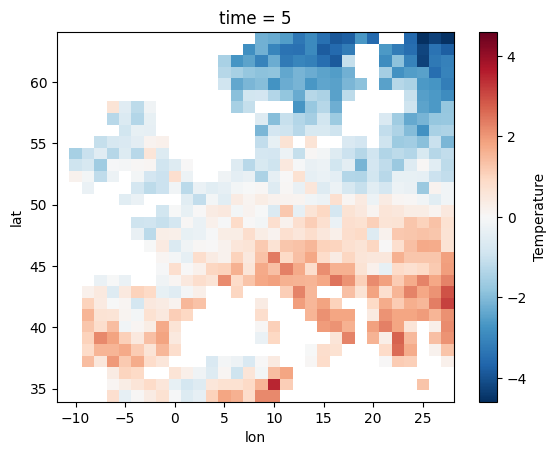

47
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


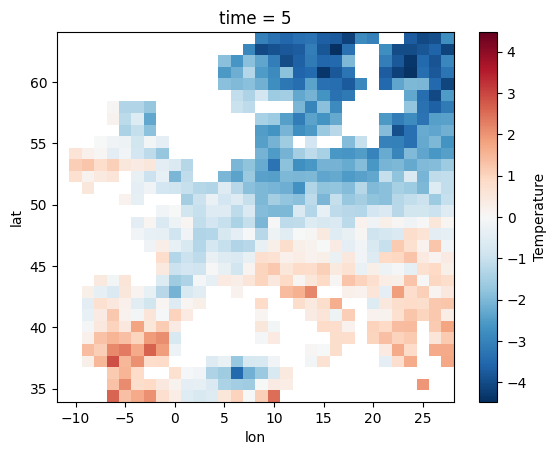

48
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


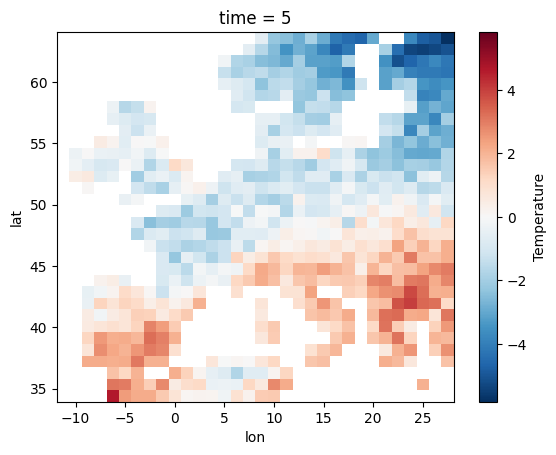

49
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


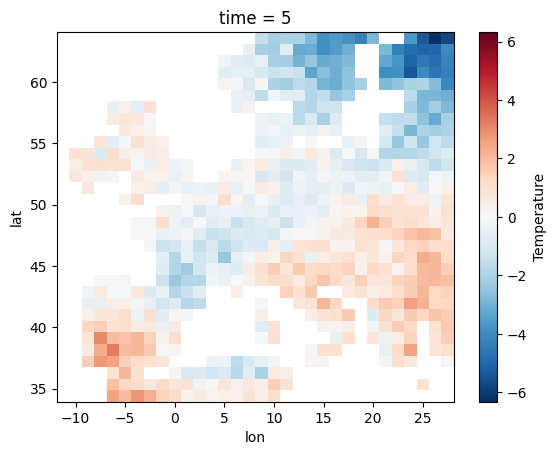

50
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


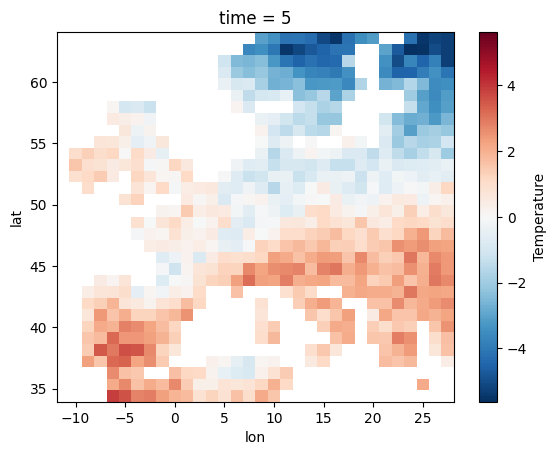

51
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


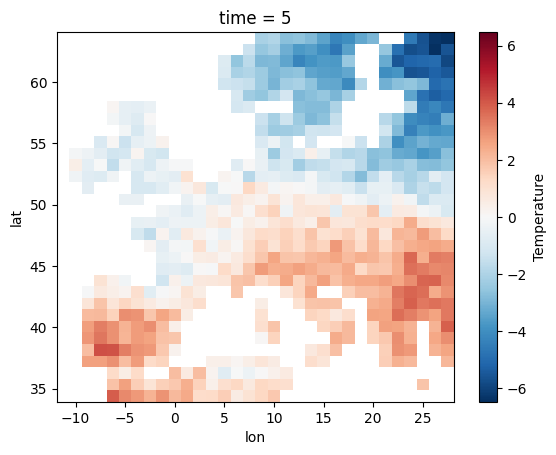

52
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


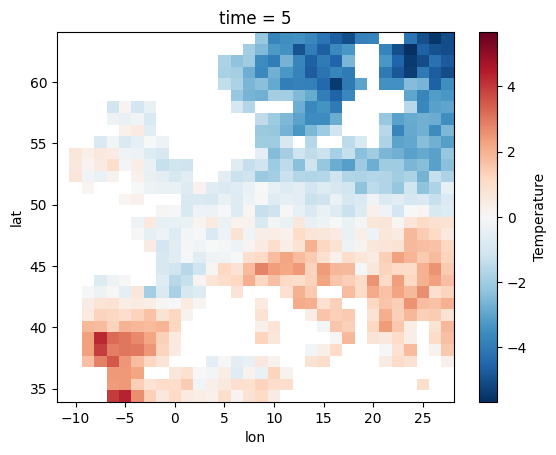

53
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


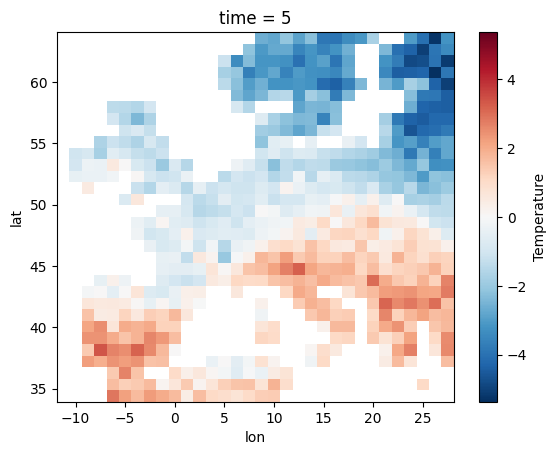

54
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


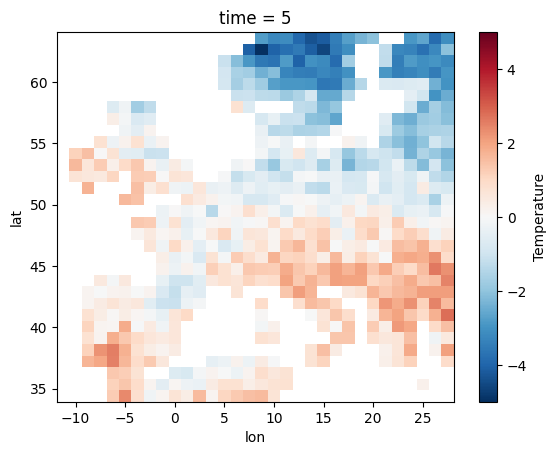

55
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


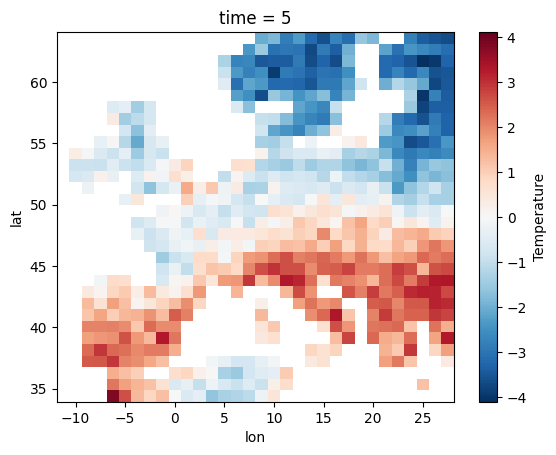

56
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


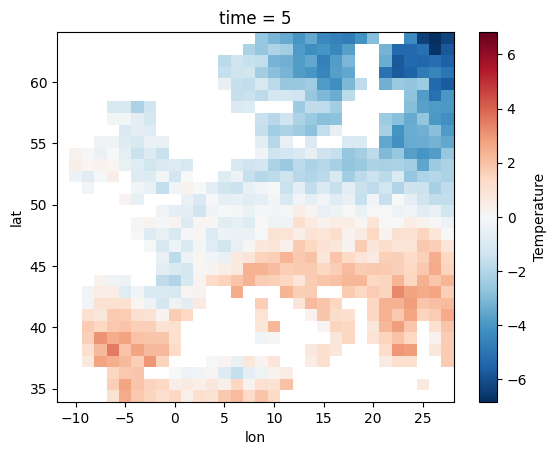

57
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


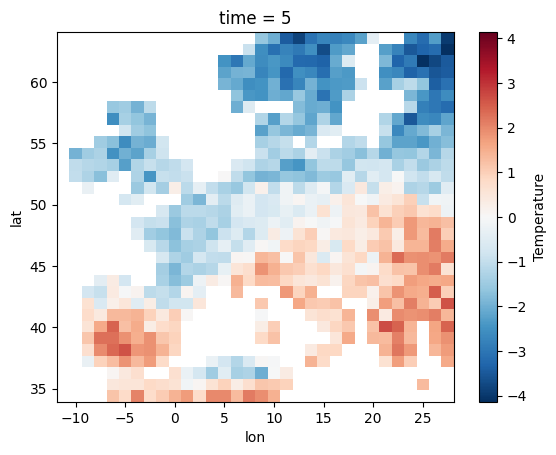

58
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


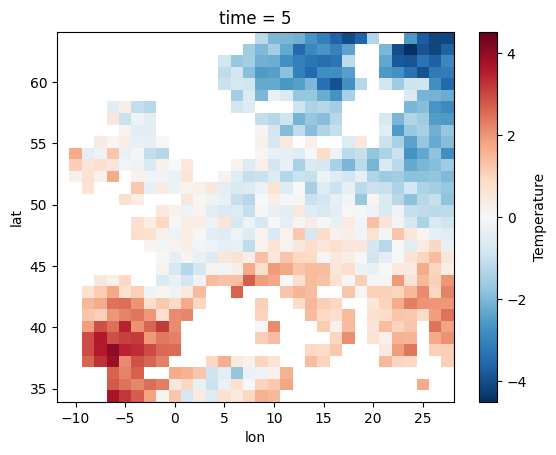

59
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


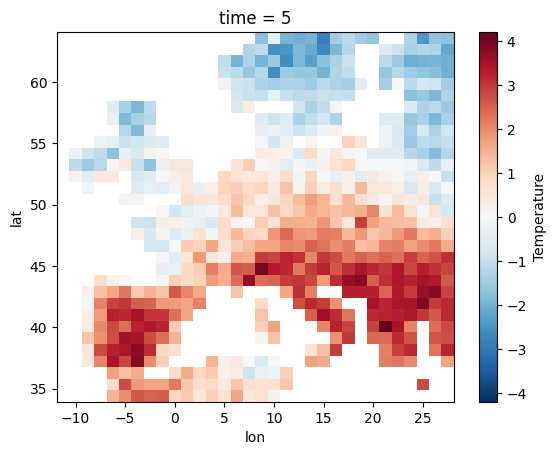

60
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


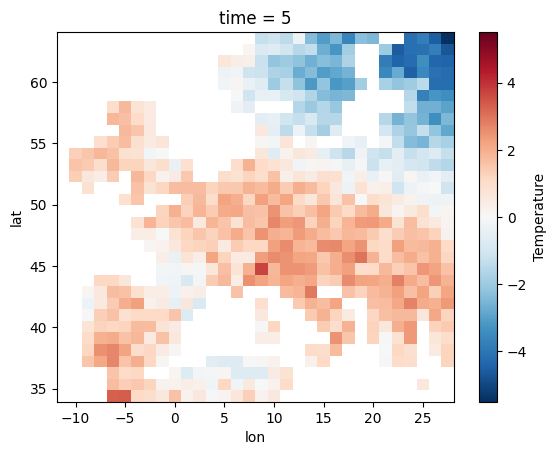

61
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


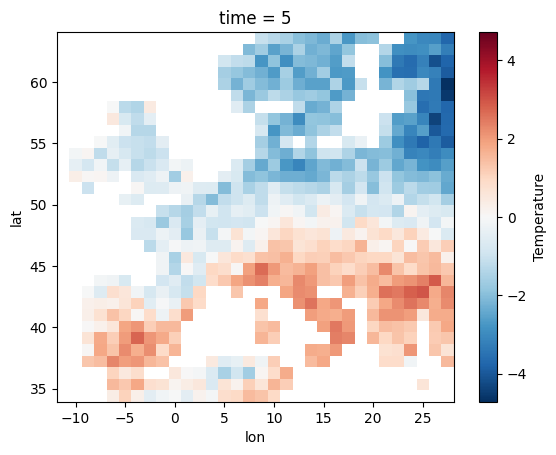

62
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


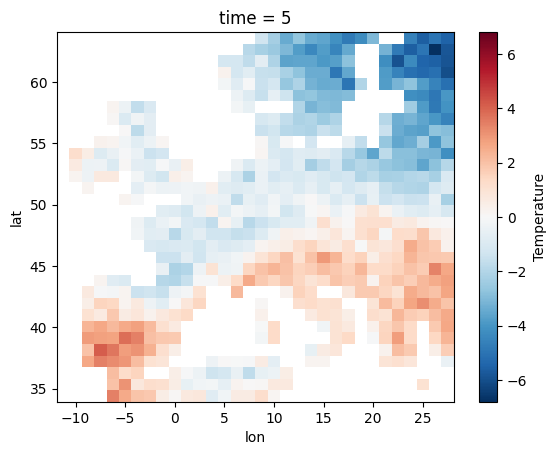

63
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


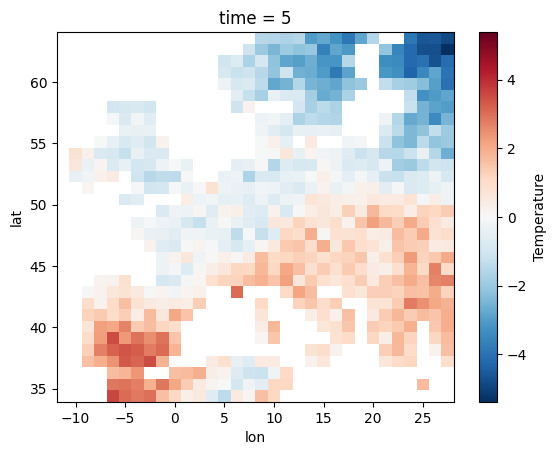

64
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


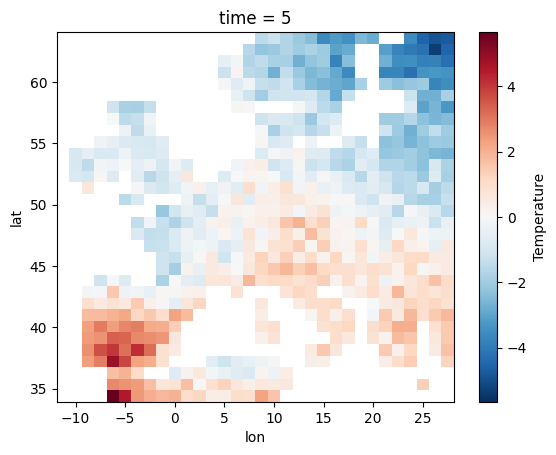

65
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


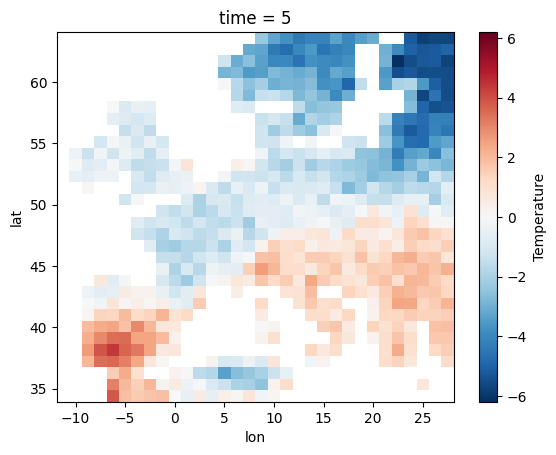

66
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


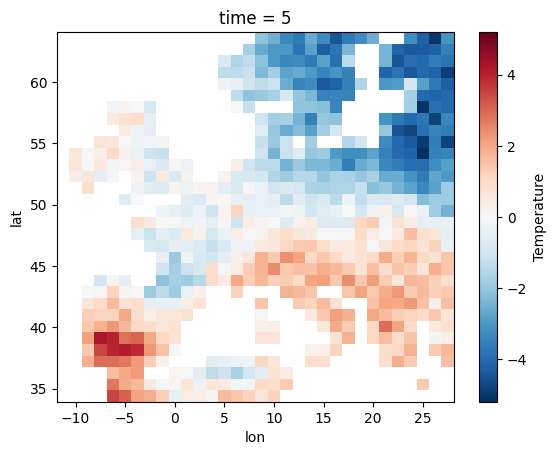

67
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


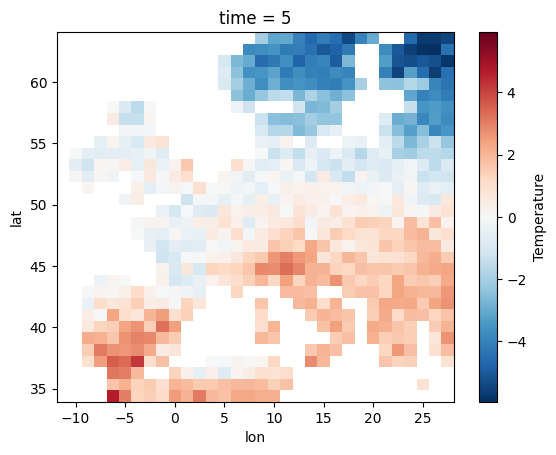

68
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


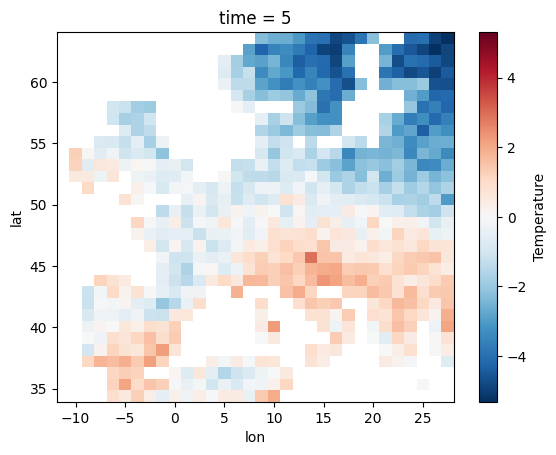

69
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


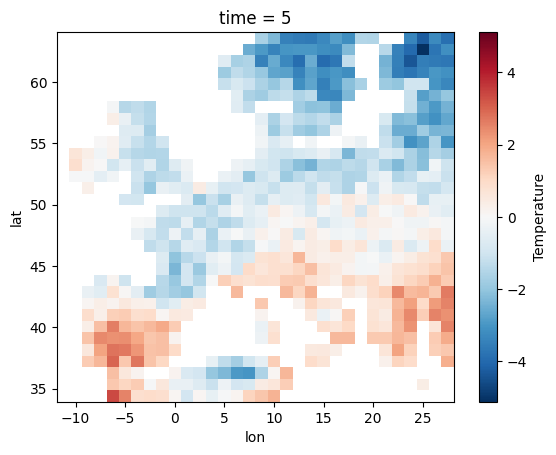

70
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


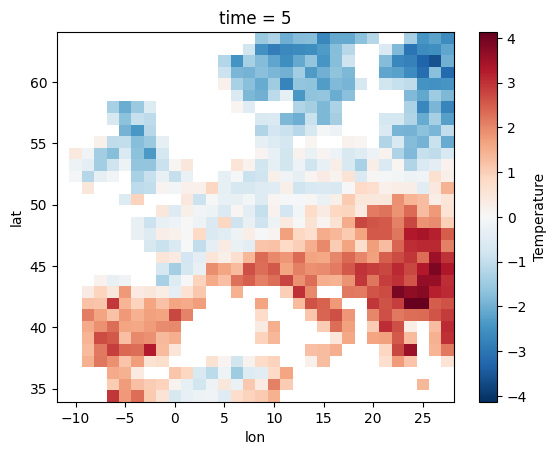

71
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


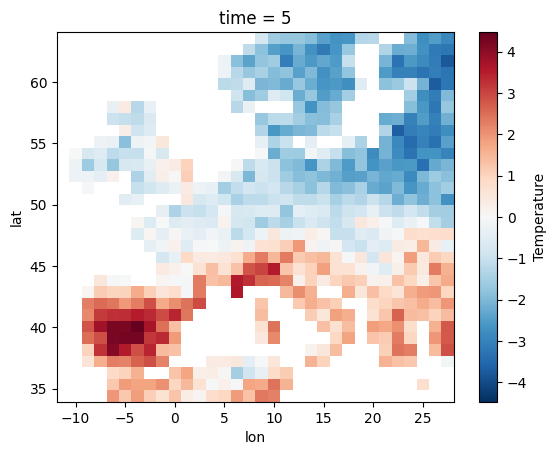

72
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


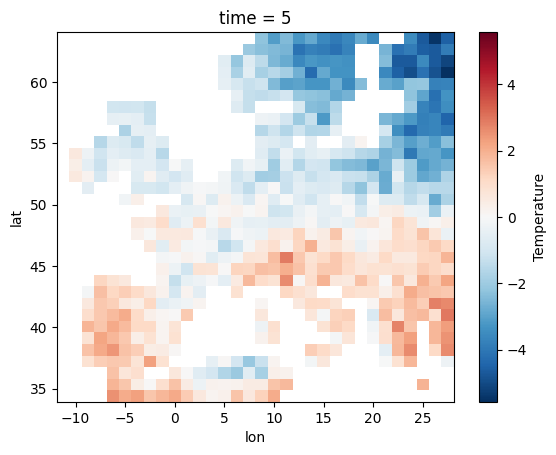

73
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


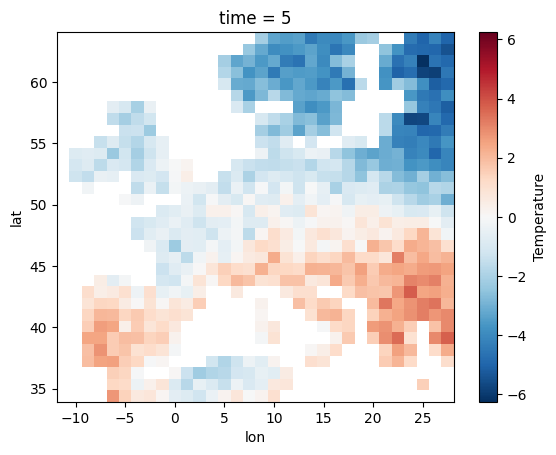

74
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


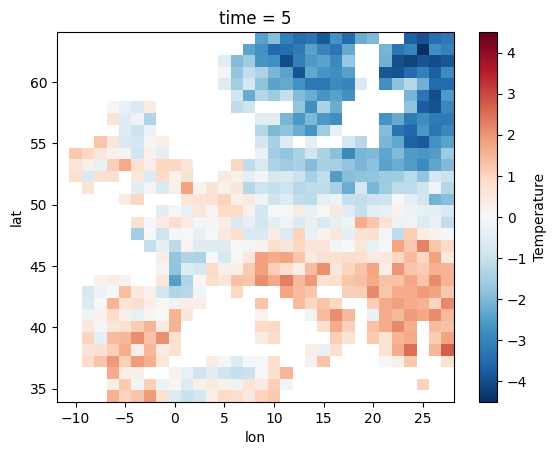

75
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


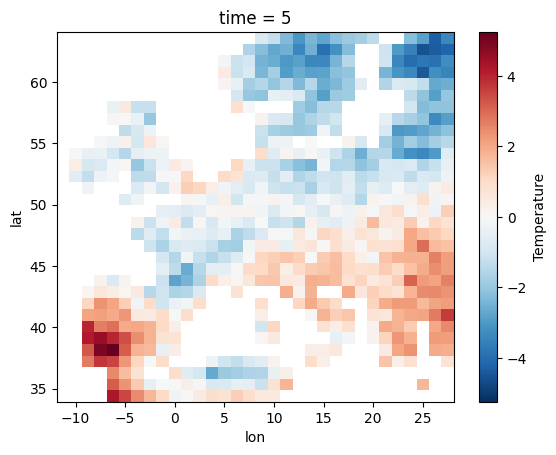

76
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


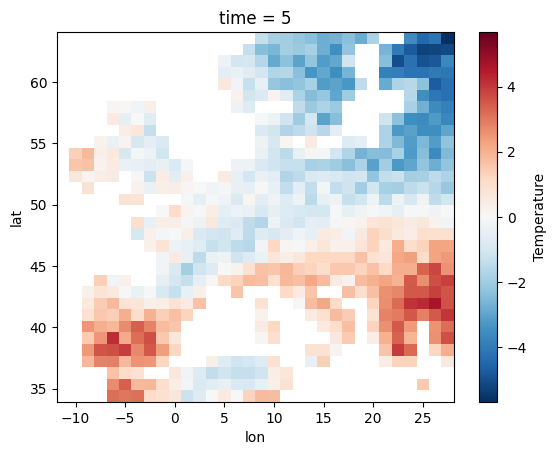

77
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


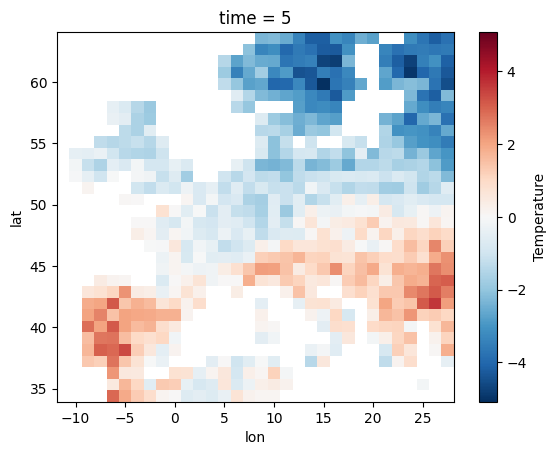

78
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


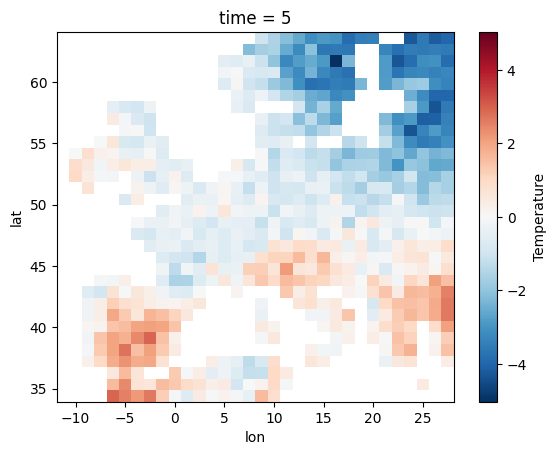

79
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


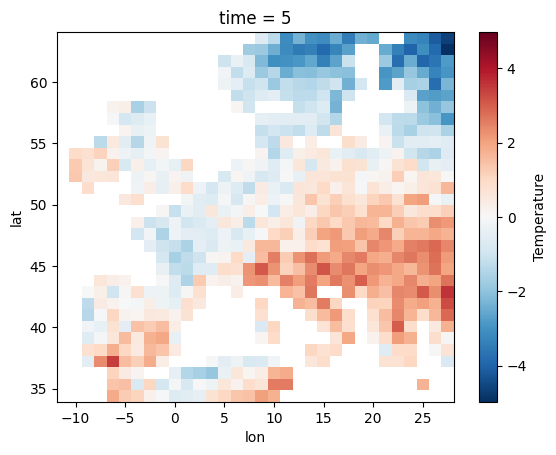

80
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


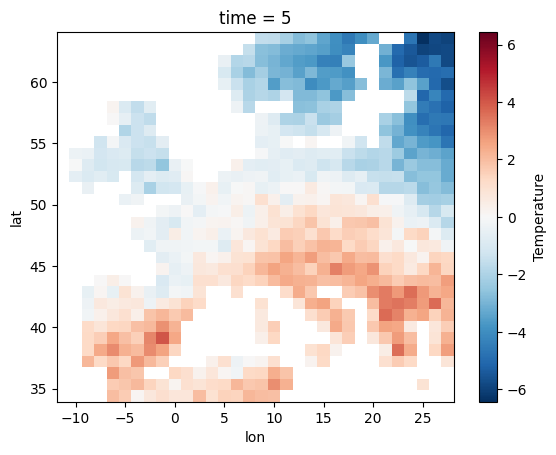

81
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


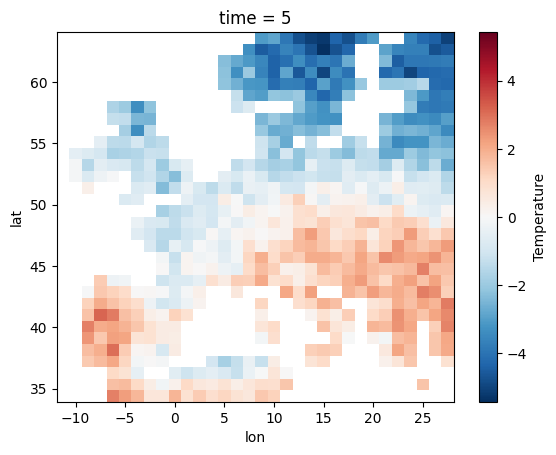

82
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


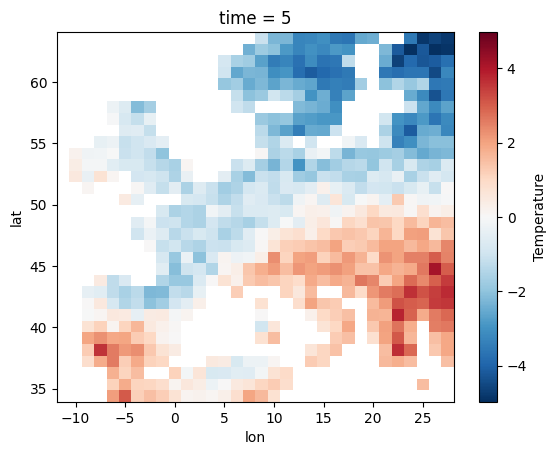

83
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


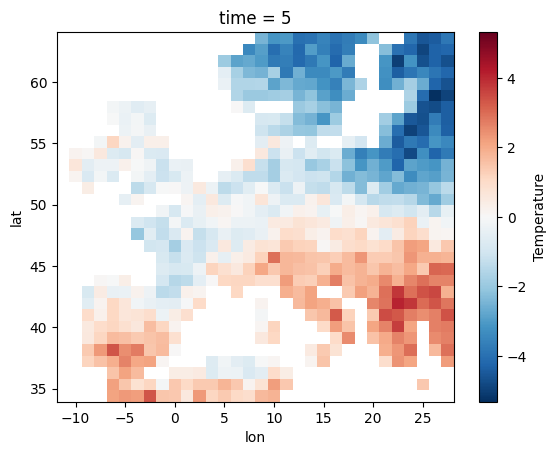

84
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


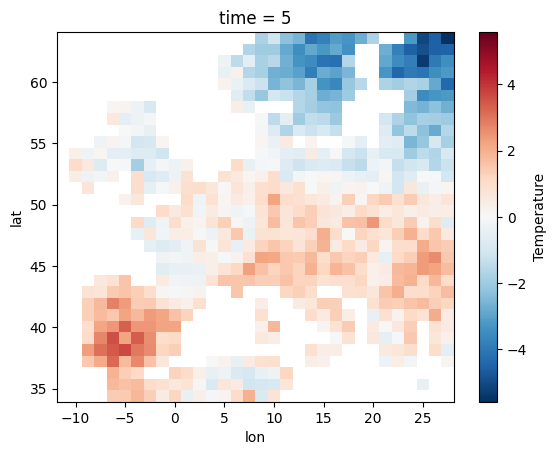

85
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


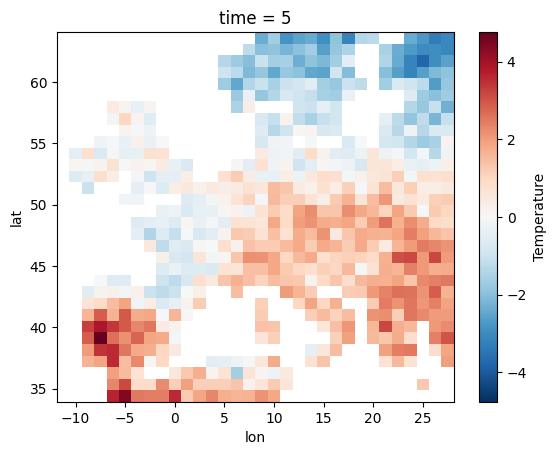

86
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


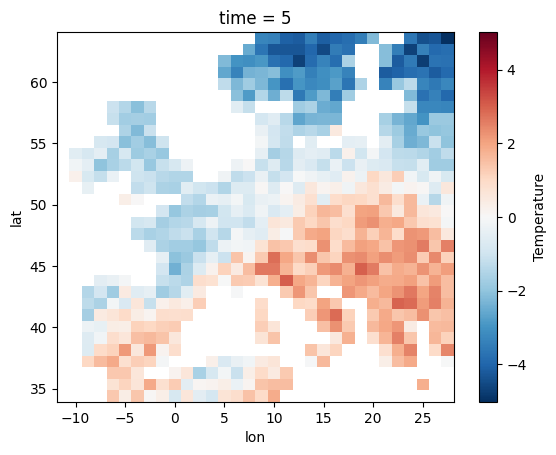

87
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


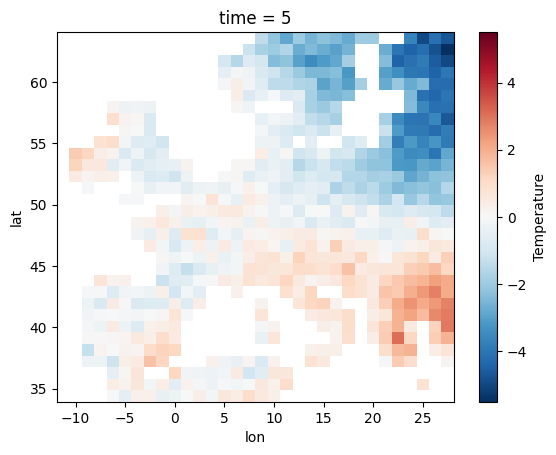

88
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


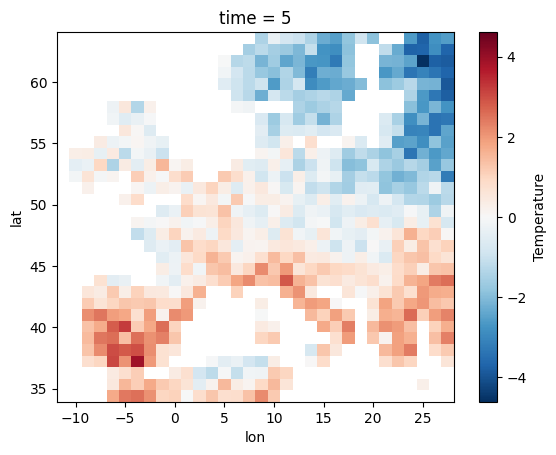

89
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


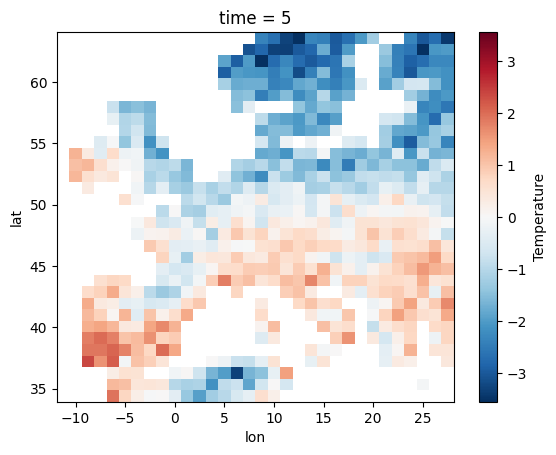

90
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


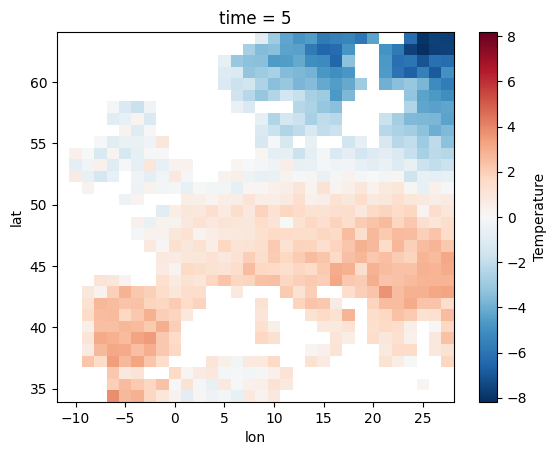

91
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


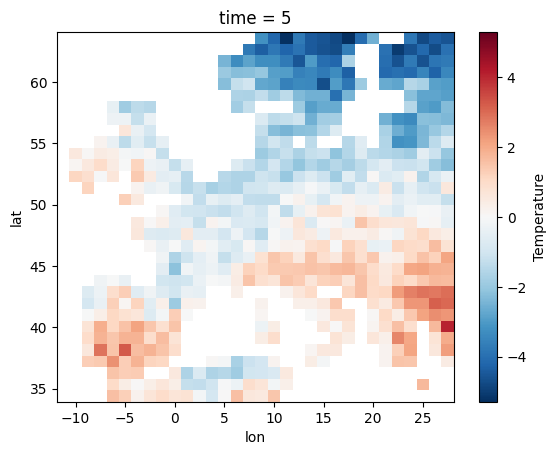

92
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


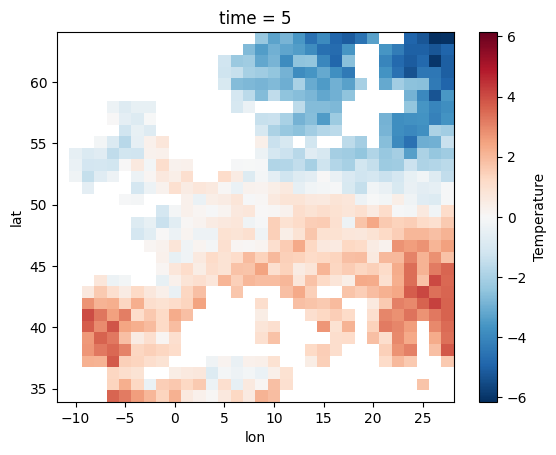

93
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


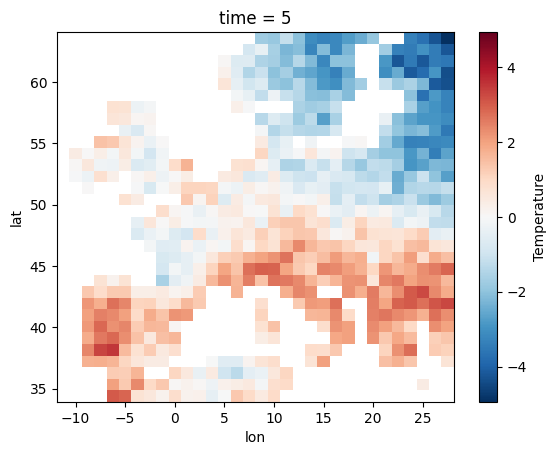

94
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


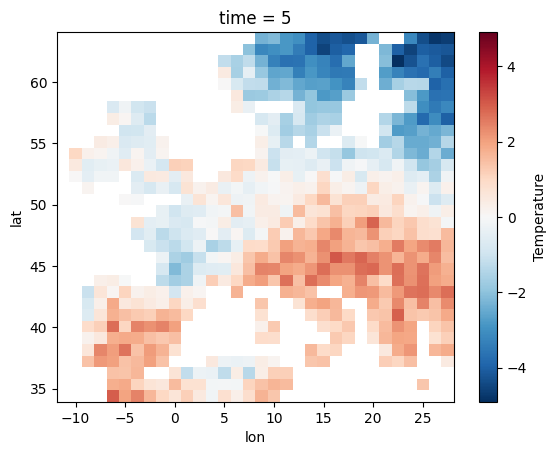

95
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


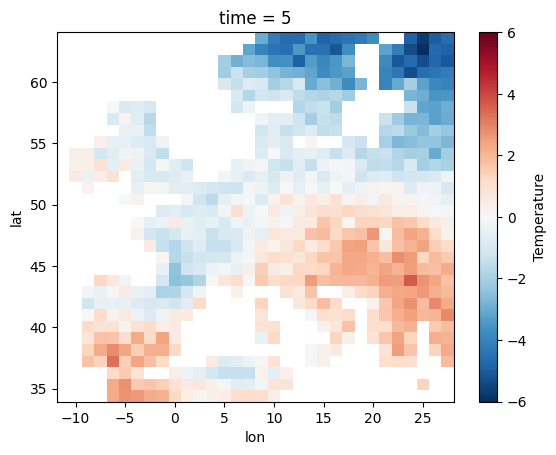

96
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


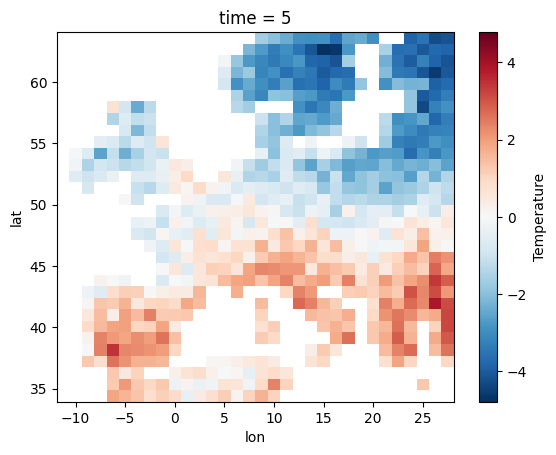

97
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


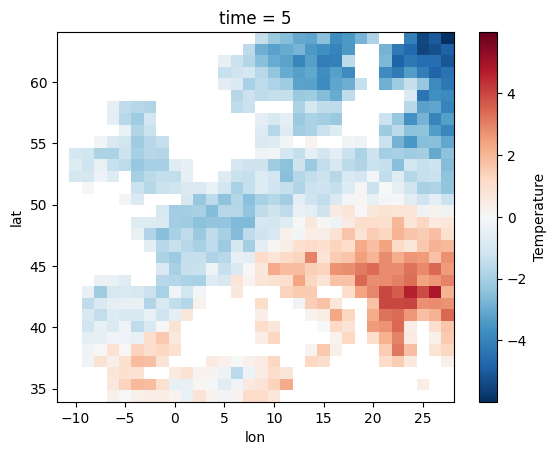

98
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


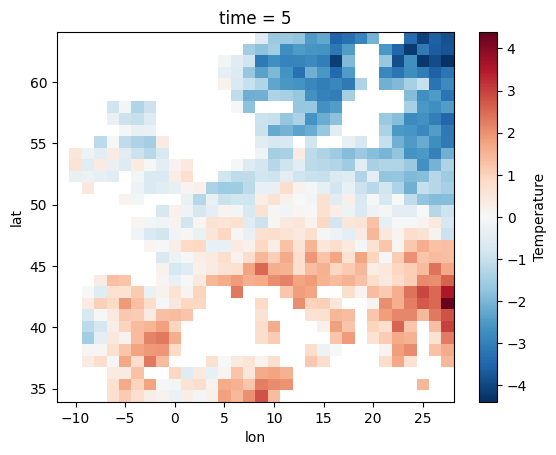

99
torch.Size([14307, 648])
torch.Size([14307, 1024])
input array is torch tensor
data_np dimensions: 2
(32, 32, 14307)


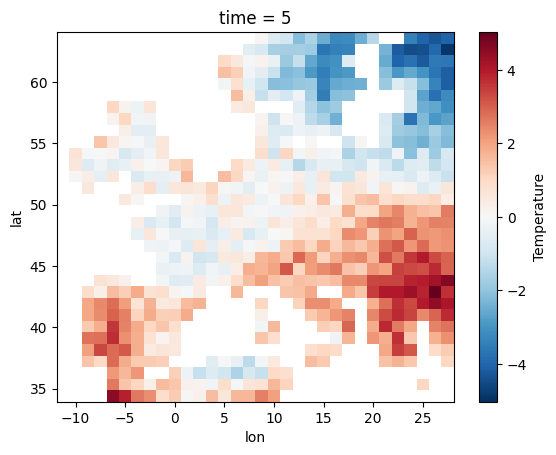

In [9]:
#import matplotlib.pyplot as plt
#torch_ensemble_restored = torch.full((100, 14307,32, 32), float("nan"))
#for i in range(100):
#    print(i)
#    print(torch_ensemble[:,:,i].shape)
#    gen1_te_from_restored = ut.restore_nan_columns(torch_ensemble[:,:,i], mask_trefht)
#    print(gen1_te_from_restored.shape)
#    reconstructed_da = torch_to_dataarray(gen1_te_from_restored, coords_ds=ds_ref, name="Temperature")
#    print(reconstructed_da.shape)
#    reconstructed_da.isel(time=5).plot()
#    plt.show()
#    torch_ensemble_restored[i,:,:,:] = torch.from_numpy(reconstructed_da.values.transpose(2,0,1))

In [9]:
torch_ensemble_restored = torch_ensemble#.transpose(2,0,1) # should have shape (ensemble_members, time, 1)

torch_ensemble_restored.shape

torch.Size([14307, 1, 100])

In [14]:
# create an xarray from it
# convert torch -> numpy (handles GPU + autograd safely)
data = torch_ensemble_restored.detach().cpu().numpy().transpose(2,0,1)[:,:,0]
print(data.shape)



ensemble_xr = xr.DataArray(
    data,
    dims=("ensemble_member", "time"),
    coords={
        "ensemble_member": np.arange(100),
        "time": ds_ref.time.isel(time=slice(0,3*4769))
        
    },
    name = "TREFHT"
)
ensemble_xr

(100, 14307)


<xarray.DataArray 'TREFHT' (ensemble_member: 100, time: 14307)> Size: 6MB
array([[-6.1624813, -3.730804 , -3.0575104, ...,  7.7281523,  6.571985 ,
         3.726022 ],
       [-6.568866 , -4.959836 , -1.679307 , ...,  7.3151107,  7.4989223,
         3.6272116],
       [-6.863343 , -3.8529334, -1.7787095, ...,  7.4261723,  5.031429 ,
         3.574069 ],
       ...,
       [-5.732959 , -3.4725122, -2.6136944, ...,  7.079569 ,  5.185772 ,
         2.836961 ],
       [-5.755663 , -4.240716 , -1.9821309, ...,  5.365178 ,  4.2872915,
         2.9576302],
       [-6.0253797, -4.3980517, -2.6939738, ...,  7.252271 ,  6.094906 ,
         3.2627525]], shape=(100, 14307), dtype=float32)
Coordinates:
  * ensemble_member  (ensemble_member) int64 800B 0 1 2 3 4 5 ... 95 96 97 98 99
  * time             (time) object 114kB 1850-06-02 00:00:00 ... 2100-08-31 0...

In [15]:
#ensemble_xr.to_netcdf("/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/StoNet/v4_data_1d_ger_trained_30_epochs_predictions_dataset.nc")